In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import nuttall
from matplotlib.colors import LogNorm
import pkfuncs as pfunc
import scipy
from scipy.signal import windows
import plot_scripts as plts

plt.style.use("mplstyle")

In [2]:
# input model power spectrum
n = 2.0
N = 768
dnuc = 40e-3            # MHz
r = 9209.714526830916 # Mpc
rp = 16.98990953034521  # Mpc/MHz
dL = dnuc * rp
L  = N * dL
Nrea = 100

k_model = np.logspace(-4, 4, 5000)
P_model = k_model**(-n)

# EoR 21-cm PS for Mondal+17
PK21 = np.load('PK21.npy')
k_model = PK21[:, 0]
P_model = PK21[:, 1]


k_fft = 2*np.pi*np.arange(N)/L
k_abs = np.abs(k_fft)

P_cont = np.interp(k_abs, k_model, P_model , left=0, right=0)

# Discrete variance for FFT modes
P_dft = (N**2 / L) * P_cont 

# binning 
NB = 64  # number of bins


In [3]:
INP_SIGNAL_CONFIGS = {
    "21cm": dict(type="21cm"),
    "FG+21cm": dict(type="FG+21cm"),
    "FG+MM+21cm": dict(type="FG+MM+21cm"),
}


# -----------------------------
# FLAG configurations
# -----------------------------
FLAG_CONFIGS = {
    "NOFLAG": dict(mode="NOFLAG", percent=0, seed=42),
    "RANDOM35": dict(mode="RANDOM", percent=35, seed=42),
    "PERIODIC": dict(mode="PERIODIC", percent=0, seed=42),
    "PERIODIC+RANDOM10": dict(mode="PERIODIC+RANDOM", percent=10, seed=42),
}



In [4]:
# def generate_fields(inp_signal, *, N, Nrea, P_dft):
#     # 21-cm realizations (always needed)
#     fields_21cm = np.array(
#         [pfunc.draw_field_from_power(P_dft, seed=55 + i) for i in range(Nrea)]
#     )

#     if inp_signal == "21cm":
#         return fields_21cm

#     if inp_signal == "FG+21cm":
#         fields_forg = pfunc.generate_gp_realizations(
#             Npoints=N,
#             amplitude=1e12,
#             length_scale=1e4,
#             Nreal=Nrea,
#             kernel_type="RBF",
#             sigma=1,
#         )
#         return fields_forg + fields_21cm

#     if inp_signal == "FG+MM+21cm":
#         fields_forg = pfunc.generate_gp_realizations(
#             Npoints=N,
#             amplitude=1e12,
#             length_scale=1e2,
#             Nreal=Nrea,
#             kernel_type="RBF",
#             sigma=1,
#         )
#         return fields_forg + fields_21cm

#     raise ValueError(f"Unknown inp_signal: {inp_signal}")


In [5]:
inp_signal = '21cm'
# fields_21cm = generate_fields(inp_signal=inp_signal, N=N, Nrea=Nrea, P_dft=P_dft)
fields_21cm = np.array(
        [pfunc.draw_field_from_power(P_dft, seed=55 + i) for i in range(Nrea)]
    )
np.save('21cm.npy', fields_21cm)


In [6]:
fields_forg1 = pfunc.generate_gp_realizations(
            Npoints=N,
            amplitude=1e12,
            length_scale=1e4,
            Nreal=Nrea,
            kernel_type="RBF",
            sigma=1,
        )

np.save('FG+21cm.npy', fields_forg1)


fields_forg2 = pfunc.generate_gp_realizations(
            Npoints=N,
            amplitude=1e12,
            length_scale=1e2,
            Nreal=Nrea,
            kernel_type="RBF",
            sigma=1,
        )

np.save('FG+MM+21cm.npy', fields_forg2)

/home/asif/miniconda3/lib/python3.8/site-packages/sklearn/gaussian_process/_gpr.py:410: RuntimeWarning: covariance is not positive-semidefinite.
  y_samples = rng.multivariate_normal(y_mean, y_cov, n_samples).T


In [7]:
for flag_key, flag_cfg in FLAG_CONFIGS.items():

    flag = pfunc.flagdata(
        N,
        mode=flag_cfg["mode"],
        percent=flag_cfg["percent"],
        seed=flag_cfg["seed"],
    )
    
    np.save(f'{flag_cfg["mode"]}.npy',flag)


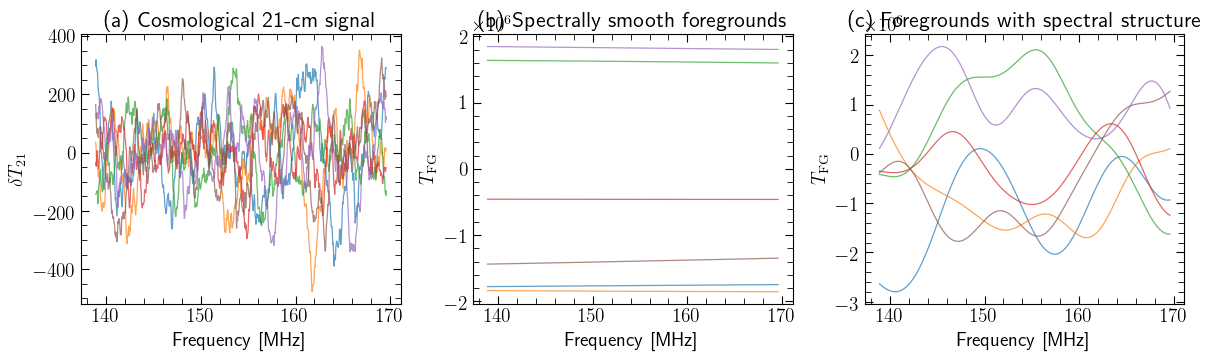

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# User controls
# -----------------------------
nplot = 6          # number of realizations to show
lw = 0.9
alpha = 0.7

# Frequency axis (MHz)
freq = np.load('nua.npy') / 1e6

# Use same realization indices everywhere
idx = np.arange(nplot)

# -----------------------------
# Figure layout: 1 row, 3 columns
# -----------------------------
fig, axes = plt.subplots(
    1, 3, figsize=(12, 3.5),
    sharey=False, constrained_layout=True
)

# -----------------------------
# (a) 21-cm signal
# -----------------------------
for i in idx:
    axes[0].plot(freq, fields_21cm[i], lw=lw, alpha=alpha)

axes[0].set_title('(a) Cosmological 21-cm signal')
axes[0].set_ylabel(r'$\delta T_{21}$')

# -----------------------------
# (b) Smooth foregrounds
# -----------------------------
for i in idx:
    axes[1].plot(freq, fields_forg1[i], lw=lw, alpha=alpha)

axes[1].set_title('(b) Spectrally smooth foregrounds')
axes[1].set_ylabel(r'$T_{\rm FG}$')

# -----------------------------
# (c) Structured foregrounds
# -----------------------------
for i in idx:
    axes[2].plot(freq, fields_forg2[i], lw=lw, alpha=alpha)

axes[2].set_title('(c) Foregrounds with spectral structure')
axes[2].set_ylabel(r'$T_{\rm FG}$')

# -----------------------------
# X-axis (shared style)
# -----------------------------
for ax in axes:
    ax.set_xlabel(r'Frequency [MHz]')

# -----------------------------
# Save
# -----------------------------
plt.savefig('plots/simulated_signals_realizations.pdf', dpi=300)
plt.show()


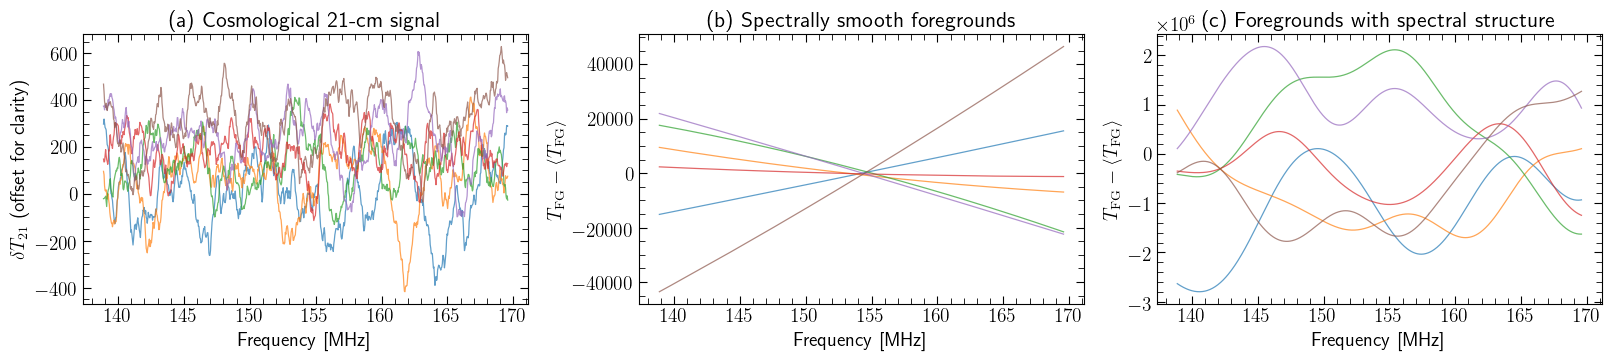

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# User controls
# -----------------------------
nplot = 6
lw = 0.9
alpha = 0.7

freq = np.load('nua.npy') / 1e6  # MHz
idx = np.arange(nplot)

# Small vertical offsets for 21-cm
sig_rms = np.std(fields_21cm)
offset_21 = 0.5 * sig_rms

# -----------------------------
# Figure layout: 1 x 3
# -----------------------------
fig, axes = plt.subplots(
    1, 3, figsize=(16, 3.5),
    constrained_layout=True
)

# -----------------------------
# (a) 21-cm signal (offset for clarity)
# -----------------------------
for j, i in enumerate(idx):
    axes[0].plot(freq,
                 fields_21cm[i] + j * offset_21,
                 lw=lw, alpha=alpha)

axes[0].set_title('(a) Cosmological 21-cm signal')
axes[0].set_ylabel(r'$\delta T_{21}$ (offset for clarity)')

# -----------------------------
# (b) Smooth foregrounds (mean-subtracted)
# -----------------------------
for i in idx:
    fg = fields_forg1[i]
    fg_ms = fg - np.mean(fg)
    axes[1].plot(freq, fg_ms, lw=lw, alpha=alpha)

axes[1].set_title('(b) Spectrally smooth foregrounds')
axes[1].set_ylabel(r'$T_{\rm FG}-\langle T_{\rm FG}\rangle$')

# -----------------------------
# (c) Structured foregrounds (mean-subtracted)
# -----------------------------
for i in idx:
    fg = fields_forg2[i]
    fg_ms = fg - np.mean(fg)*0
    axes[2].plot(freq, fg_ms, lw=lw, alpha=alpha)

axes[2].set_title('(c) Foregrounds with spectral structure')
axes[2].set_ylabel(r'$T_{\rm FG}-\langle T_{\rm FG}\rangle$')

# -----------------------------
# X-axis
# -----------------------------
for ax in axes:
    ax.set_xlabel(r'Frequency [MHz]')

# -----------------------------
# Save
# -----------------------------
plt.savefig('plots/simulated_signals_realizations.pdf', dpi=300)
plt.show()
